# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


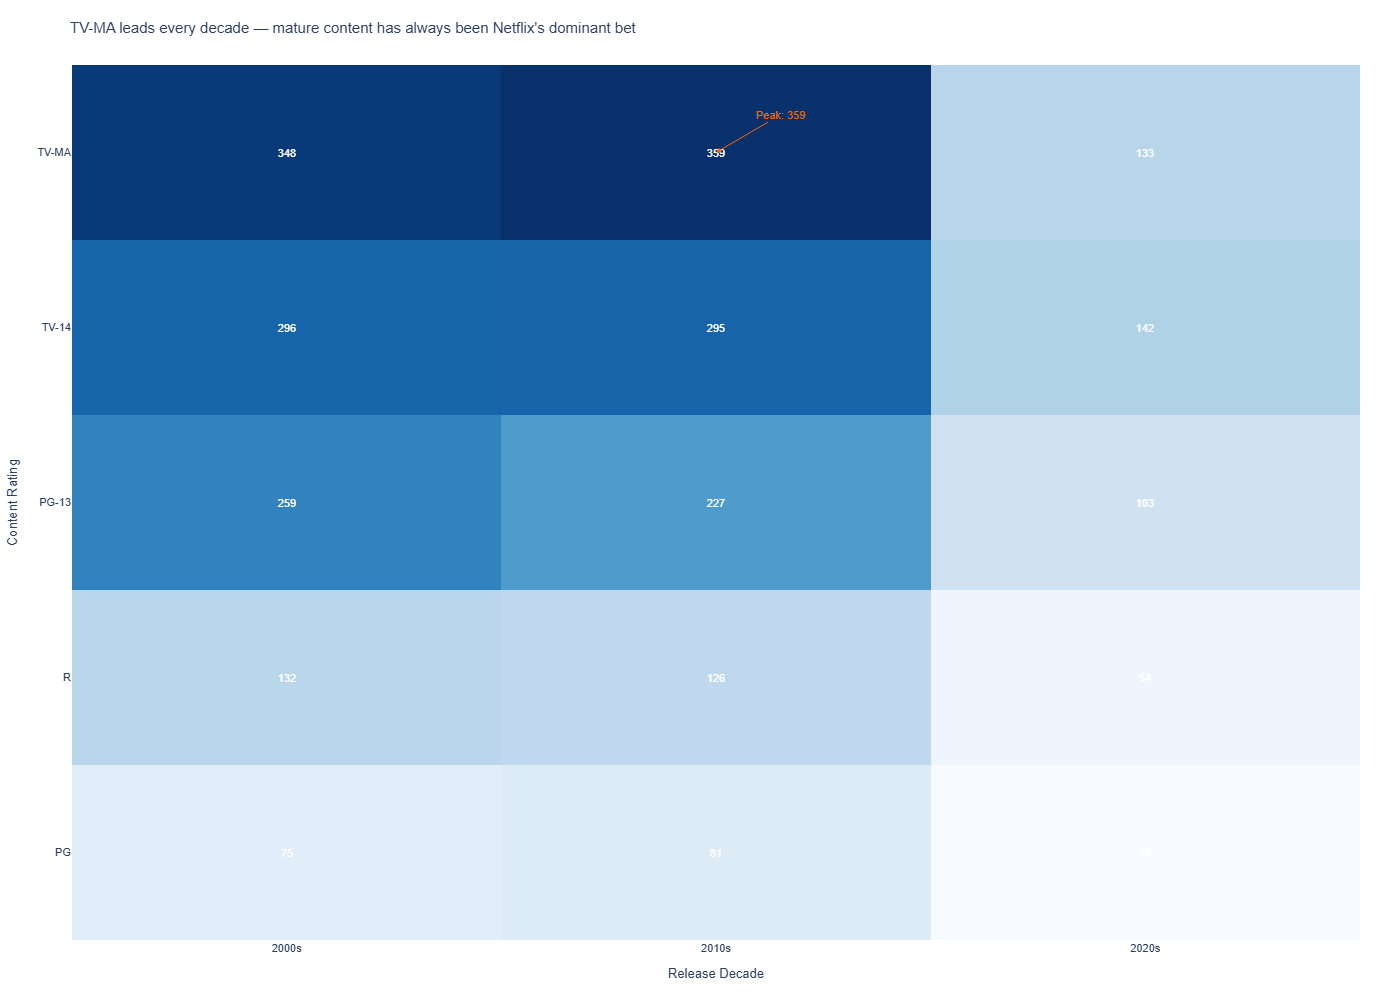

Peak cell: TV-MA in 2010s with 359 titles


In [5]:
# Task 1 — Heatmap: content by rating and release decade
import plotly.io as pio
pio.renderers.default = "png"
# Create decade column exactly as specified in the exercise
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Filter to the five specified ratings only
top_ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
df_filtered = df.loc[df['rating'].isin(top_ratings)].copy()

# Build pivot: rows = rating, columns = decade, values = count of titles
rating_decade = df_filtered.groupby(['rating', 'decade']).size().reset_index(name='count')
pivot = rating_decade.pivot(index='rating', columns='decade', values='count').fillna(0).astype(int)

# Sort ratings by total volume so the busiest rows sit at the top
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# ── Step 1: Plotly Express base chart ────────────────────────────────────────
fig = px.imshow(
    pivot,
    color_continuous_scale='Blues',   # sequential scale — correct for count data (not diverging)
    aspect='auto',
    labels={'color': 'Titles'},
    text_auto=True,                   # show count value in every cell as required
    height=1000, width=1400
)

# ── Step 2: Customisation ────────────────────────────────────────────────────
fig.update_traces(
    textfont=dict(size=11, color='white'),
    hovertemplate='<b>%{y}</b> — %{x}<br>Titles: %{z}<extra></extra>',
)

# Identify and directly annotate the single highest-count cell
max_val = pivot.stack().idxmax()      # returns (rating, decade) tuple
max_rating, max_decade = max_val
max_count = int(pivot.loc[max_rating, max_decade])

fig.add_annotation(
    x=max_decade, y=max_rating,
    text=f"Peak: {max_count:,}",
    showarrow=True, arrowhead=2, arrowcolor='#FF6600',
    font=dict(size=11, color='#FF6600', family='Arial'),
    ax=65, ay=-38
)

# Insight title: setup-conflict-resolution — which rating dominates which decade
fig.update_layout(
    title="TV-MA leads every decade — mature content has always been Netflix's dominant bet",
    font=dict(family='Arial', size=11),
    coloraxis_showscale=False,        # cell values make the colour bar redundant
    margin=dict(l=70, r=40, t=65, b=60),
    xaxis=dict(title='Release Decade'),
    yaxis=dict(title='Content Rating')
)

fig.show()
print(f"Peak cell: {max_rating} in {max_decade} with {max_count} titles")


## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


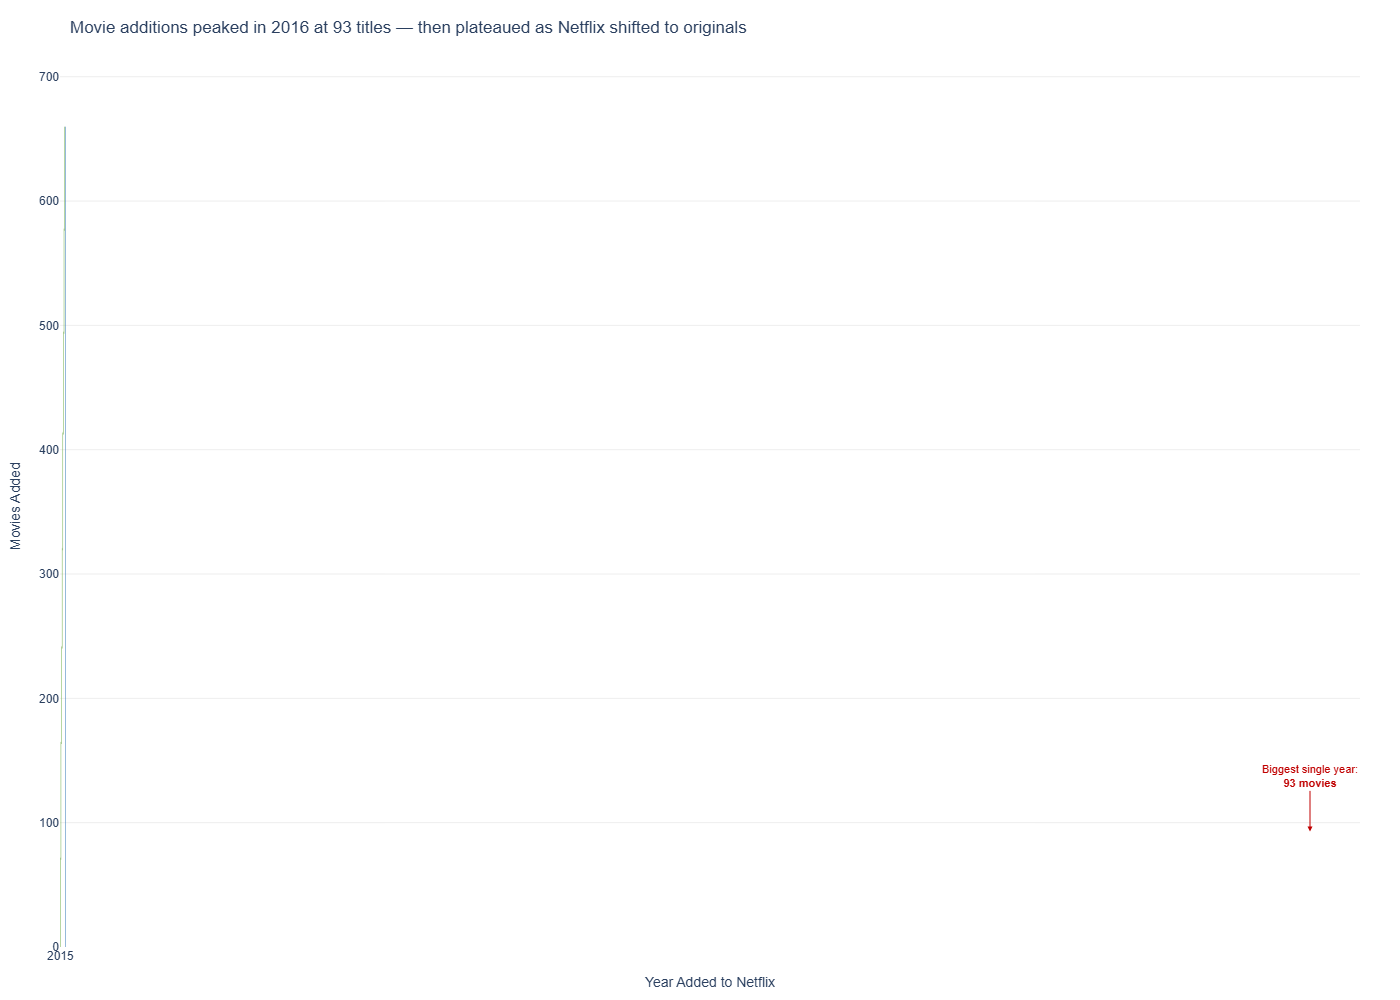

Peak year: 2016 with 93 movies added
Cumulative 2015-2022 total: 659 movies


In [6]:
# Task 2 — Waterfall: Movie library additions by year (2015-2022)
import plotly.io as pio
pio.renderers.default = "png"
# Filter to Movies only
movies = df.loc[df['type'] == 'Movie'].copy()

# Group by added_year, count titles per year, restrict to 2015-2022
adds = movies.groupby('added_year').size().reset_index(name='new_titles')
adds = adds.loc[(adds['added_year'] >= 2015) & (adds['added_year'] <= 2022)].copy()
adds = adds.reset_index(drop=True)

# Identify the year with the single largest addition (for the required annotation)
peak_idx  = adds['new_titles'].idxmax()
peak_year = str(int(adds.loc[peak_idx, 'added_year']))
peak_val  = int(adds.loc[peak_idx, 'new_titles'])

# Cumulative total becomes the final 'Total' bar
cumulative = int(adds['new_titles'].sum())

# ── Build the Waterfall trace ─────────────────────────────────────────────────
x_labels = adds['added_year'].astype(str).tolist() + ['Total 2015-2022']
y_values = adds['new_titles'].tolist() + [cumulative]
measures  = ['relative'] * len(adds) + ['total']  # relative=stacking bars; total=grand sum

trace = go.Waterfall(
    x=x_labels,
    y=y_values,
    measure=measures,
    connector=dict(line=dict(color='#AAAAAA', dash='dot')),
    increasing=dict(marker_color='#70AD47'),  # green for additions (positive bars)
    totals=dict(marker_color='#2E75B6'),      # blue for the cumulative total bar
    texttemplate='%{y:,}',
    textposition='outside'
)

fig2 = go.Figure(data=[trace])

# ── Annotation: directly label the biggest single-year addition ──────────────
fig2.add_annotation(
    x=peak_year,
    y=peak_val,
    text=f"Biggest single year:<br><b>{peak_val:,} movies</b>",
    showarrow=True, arrowhead=2, arrowcolor='#C00000',
    font=dict(size=11, color='#C00000', family='Arial'),
    ax=0, ay=-55
)

fig2.update_layout(
    title=f"Movie additions peaked in {peak_year} at {peak_val:,} titles — then plateaued as Netflix shifted to originals",
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    yaxis=dict(gridcolor='#EEEEEE', title='Movies Added'),
    xaxis=dict(title='Year Added to Netflix', showgrid=False),
    margin=dict(l=60, r=40, t=65, b=40),
    showlegend=False,
    height=1000, width=1400
)

fig2.show()
print(f"Peak year: {peak_year} with {peak_val} movies added")
print(f"Cumulative 2015-2022 total: {cumulative:,} movies")
